In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

In [3]:
df = pd.read_csv('../ARIMA,SARIMA,SARIMAX/daily_revenue.csv',index_col = 'date', parse_dates = True, dayfirst = True)
df.head()

,revenue,discount_rate,coupon_rate
date,,,
2018-01-01,"6,270,839",34.27%,1.09%
2018-01-02,"8,922,076",30.87%,1.08%
2018-01-03,"8,446,101",28.11%,1.01%
2018-01-04,"7,785,798",27.32%,0.96%
2018-01-05,"6,375,303",25.70%,0.90%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   revenue        1795 non-null   object
 1   discount_rate  1795 non-null   object
 2   coupon_rate    1795 non-null   object
dtypes: object(3)
memory usage: 56.1+ KB


In [5]:
# Transform revenue into a float
df['revenue'] = df['revenue'].str.replace(',', '').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1795 entries, 2018-01-01 to 2022-11-30
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   revenue        1795 non-null   float64
 1   discount_rate  1795 non-null   object 
 2   coupon_rate    1795 non-null   object 
dtypes: float64(1), object(2)
memory usage: 56.1+ KB


In [6]:
# Setting the frequence
df = df.asfreq('D')

In [8]:
# change the time series vairable name
df.rename(columns = {'revenue':'y'}, inplace = True)
df.head()

,y,discount_rate,coupon_rate
date,,,
2018-01-01,6270839.0,34.27%,1.09%
2018-01-02,8922076.0,30.87%,1.08%
2018-01-03,8446101.0,28.11%,1.01%
2018-01-04,7785798.0,27.32%,0.96%
2018-01-05,6375303.0,25.70%,0.90%


# EDA

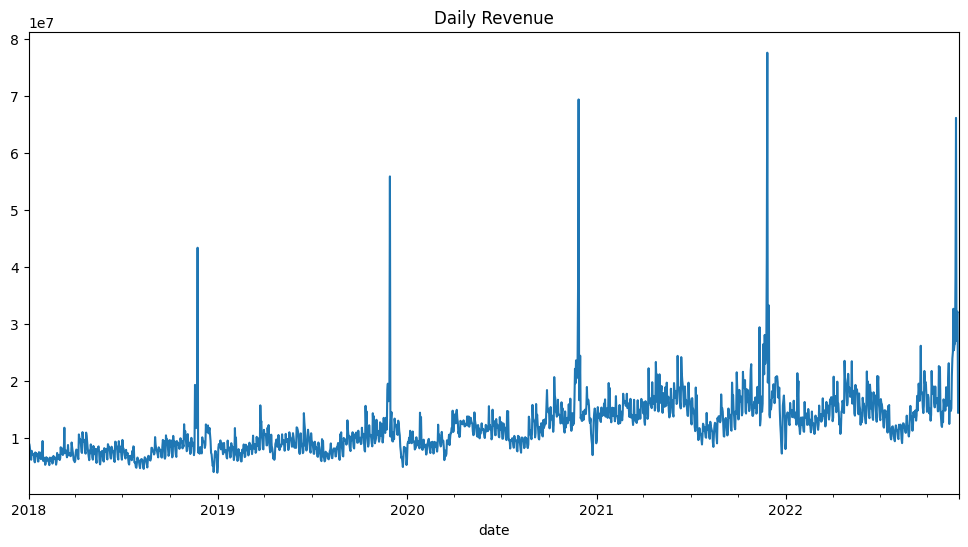

In [10]:
# Daily revenue plot
df['y'].plot(figsize = (12,6))
plt.title('Daily Revenue')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_28108\3885018770.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_plot(df['y'].resample('M').mean(), ylabel='Revenue')


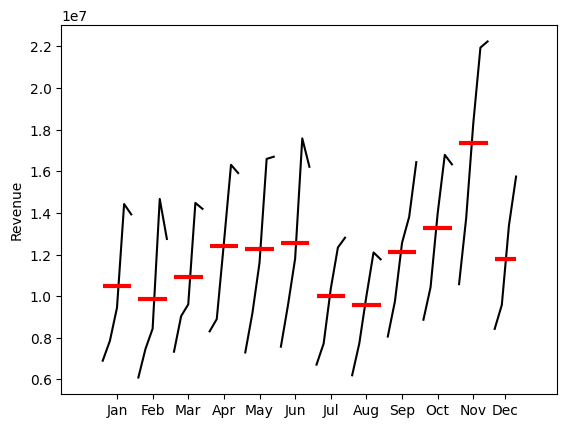

In [14]:
# Plot the monthly seasonality
month_plot(df['y'].resample('M').mean(), ylabel='Revenue')
plt.show()

C:\Users\msi\AppData\Local\Temp\ipykernel_28108\3349294975.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarter_plot(df['y'].resample('Q').mean(), ylabel='Revenue')


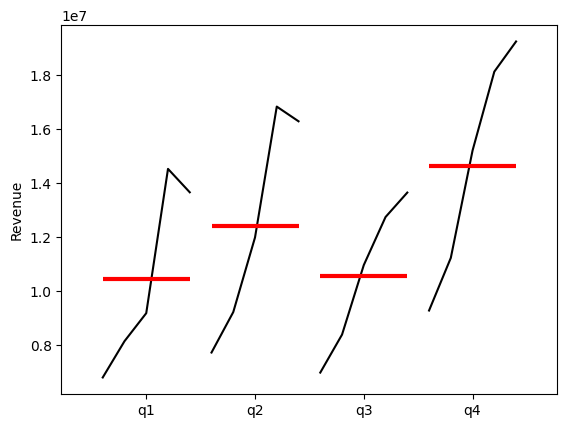

In [15]:
# plotting the quarterly seasonality
quarter_plot(df['y'].resample('Q').mean(), ylabel='Revenue')
plt.show()

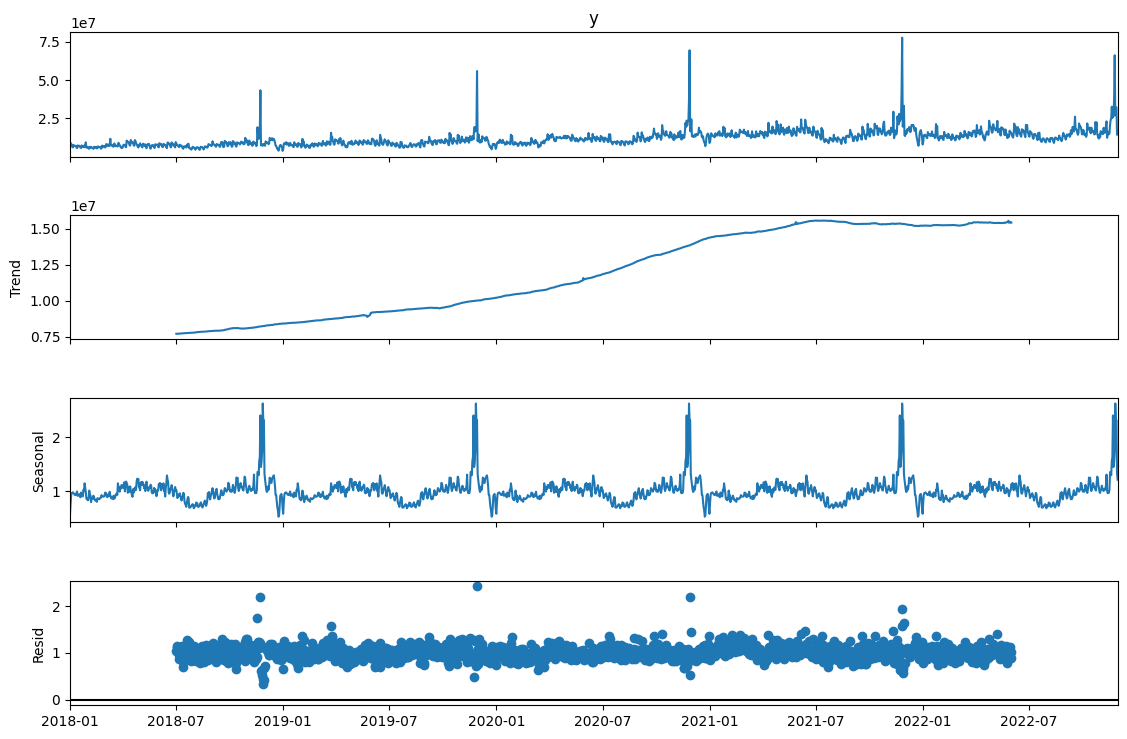

In [17]:
# seasonal decomposition
decomposition = seasonal_decompose(df['y'], model = 'multiplicative', period = 365)
fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

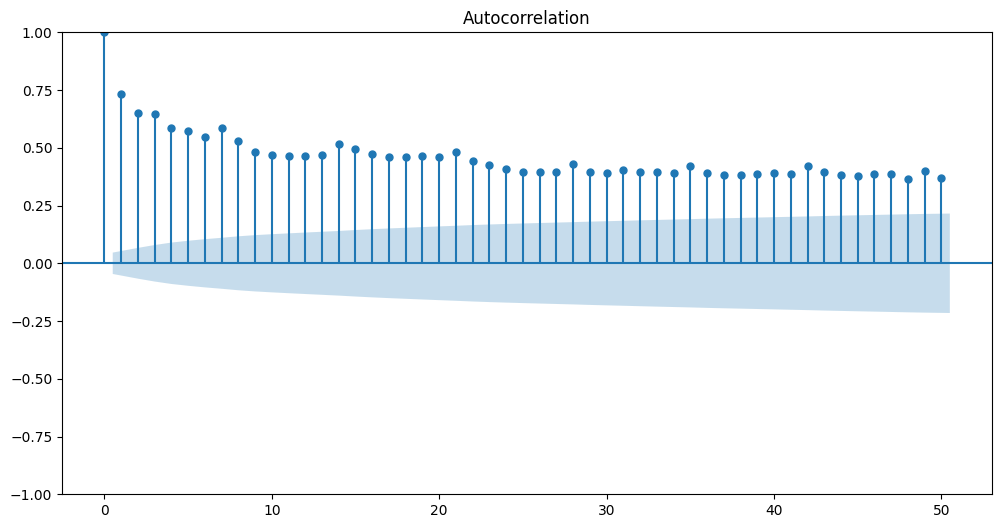

In [18]:
# Plot the auto correlation
fig, ax = plt.subplots(figsize = (12,6))
plot_acf(df['y'], lags = 50, ax = ax)
plt.show()

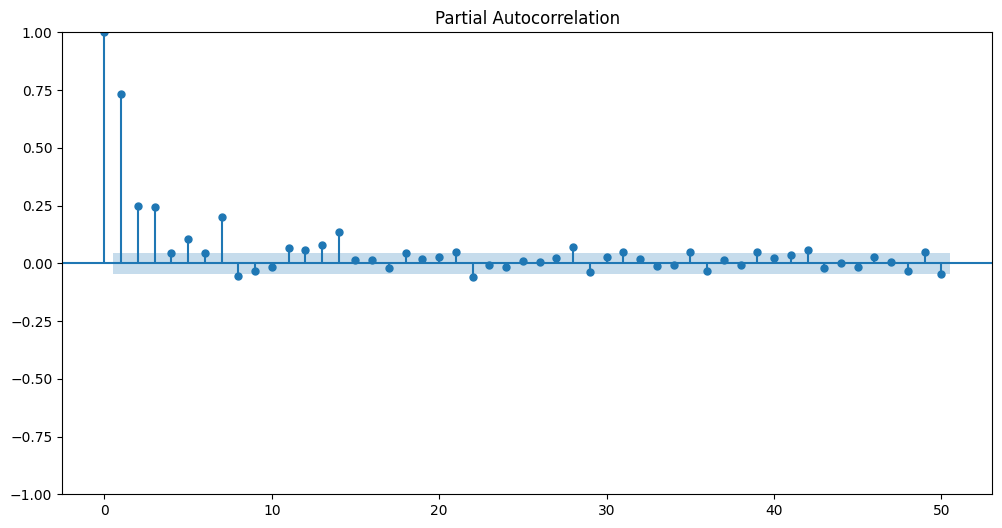

In [19]:
# Plot the partial auto correlation
fig, ax = plt.subplots(figsize = (12,6))
plot_pacf(df['y'], lags = 50, ax = ax)
plt.show()